# 06 - Publication Figures and Results Analysis (V4)

Clean, self-contained publication-figure notebook.

It **does not rerun optimization**. It loads the saved project datasets and optimization checkpoints, validates them immediately, generates analytical figures, and combines manually captured Folium PNG panels with corresponding analytical panels.

### Naming convention used throughout
`facilities`, `zones`, `demand_250`, `demand_500`, `demand_1000`, `candidate_hubs`, `run_summary`, `selected_hubs`, `assignments`, `mclp_coverage`, `lscp_uncovered`.

No `contextily` or automated OpenStreetMap tile requests are used.

## 0. Imports and directories

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from PIL import Image, ImageDraw
from PIL import Image, ImageDraw, ImageFont

PROJECT_ROOT=Path("hajj_drone_project")
PROCESSED_DIR=PROJECT_ROOT/"data"/"processed"
MODEL_DIR=PROJECT_ROOT/"data"/"model"
SOLUTION_DIR=MODEL_DIR/"optimization_solutions"
REPORT_DIR=PROJECT_ROOT/"outputs"/"reports"

FIG_DIR=PROJECT_ROOT/"outputs"/"figures"/"paper"
FOLIUM_PANEL_DIR=FIG_DIR/"folium_panels"
ANALYTICAL_PANEL_DIR=FIG_DIR/"analytical_panels"
COMBINED_DIR=FIG_DIR/"combined_v4"

for p in [FIG_DIR,FOLIUM_PANEL_DIR,ANALYTICAL_PANEL_DIR,COMBINED_DIR,REPORT_DIR]:
    p.mkdir(parents=True,exist_ok=True)

plt.rcParams.update({
    "font.size":9,
    "axes.titlesize":10,
    "axes.labelsize":9,
    "legend.fontsize":8,
    "figure.dpi":120
})

print("Project root:",PROJECT_ROOT.resolve())
print("Folium PNG folder:",FOLIUM_PANEL_DIR.resolve())
print("Combined output:",COMBINED_DIR.resolve())

Project root: C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project
Folium PNG folder: C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project\outputs\figures\paper\folium_panels
Combined output: C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project\outputs\figures\paper\combined_v4


## 1. Load all required datasets

In [2]:
paths={
"facilities":PROCESSED_DIR/"hajj_medical_locations_zoned_v1.gpkg",
"zones":PROCESSED_DIR/"hajj_analytical_zones_v1.gpkg",
"demand_250":PROCESSED_DIR/"hajj_demand_locations_250m_v1.gpkg",
"demand_500":PROCESSED_DIR/"hajj_demand_locations_500m_v1.gpkg",
"demand_1000":PROCESSED_DIR/"hajj_demand_locations_1000m_v1.gpkg",
"candidate_hubs":PROCESSED_DIR/"candidate_drone_hubs_v1.gpkg",
"run_summary":SOLUTION_DIR/"optimization_run_summary_v1.csv",
"selected_hubs":SOLUTION_DIR/"optimization_selected_hubs_v1.csv",
"assignments":SOLUTION_DIR/"optimization_assignments_v1.csv",
"mclp_coverage":SOLUTION_DIR/"optimization_mclp_coverage_v1.csv",
"lscp_uncovered":SOLUTION_DIR/"optimization_lscp_uncoverable_points_v1.csv",
}

missing=[str(p) for p in paths.values() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

facilities=gpd.read_file(paths["facilities"]).to_crs(4326)
zones=gpd.read_file(paths["zones"]).to_crs(4326)
demand_250=gpd.read_file(paths["demand_250"]).to_crs(4326)
demand_500=gpd.read_file(paths["demand_500"]).to_crs(4326)
demand_1000=gpd.read_file(paths["demand_1000"]).to_crs(4326)
candidate_hubs=gpd.read_file(paths["candidate_hubs"]).to_crs(4326)

run_summary=pd.read_csv(paths["run_summary"])
selected_hubs=pd.read_csv(paths["selected_hubs"])
assignments=pd.read_csv(paths["assignments"])
mclp_coverage=pd.read_csv(paths["mclp_coverage"])
lscp_uncovered=pd.read_csv(paths["lscp_uncovered"])

## 2. Immediate validation

In [3]:
checks=[
("Medical facilities",len(facilities),216),
("Hajj analytical zones",len(zones),4),
("250 m demand cells",len(demand_250),2192),
("500 m demand cells",len(demand_500),556),
("1000 m demand cells",len(demand_1000),142),
("Candidate hubs",len(candidate_hubs),59),
("Optimization runs",len(run_summary),108),
("Selected-hub records",len(selected_hubs),509),
("Assignment records",len(assignments),20016),
("MCLP coverage records",len(mclp_coverage),35584),
("LSCP uncovered records",len(lscp_uncovered),47),
]

print("DATA VALIDATION")
print("-"*60)
all_ok=True
for label,actual,expected in checks:
    ok=actual==expected
    all_ok &= ok
    print(f"{label:<28} {actual:>7,}   {'OK' if ok else f'EXPECTED {expected:,}'}")

required_cols={
"demand_500":["demand_point_id","centroid_lat","centroid_lon","proxy_demand_weight"],
"candidate_hubs":["category","latitude","longitude"],
"selected_hubs":["model","demand_scenario","p","range_km","hub_id","latitude","longitude"],
"assignments":["model","demand_scenario","p","range_km","demand_point_id","assigned_hub_id","distance_km"],
"mclp_coverage":["demand_scenario","p","range_km","demand_point_id","covered"]
}

objects={
"demand_500":demand_500,
"candidate_hubs":candidate_hubs,
"selected_hubs":selected_hubs,
"assignments":assignments,
"mclp_coverage":mclp_coverage
}

for name,cols in required_cols.items():
    miss=[c for c in cols if c not in objects[name].columns]
    if miss:
        raise KeyError(f"{name} missing columns: {miss}")

if not all_ok:
    print("\nWARNING: Counts differ from the V1 experiment checkpoint. Inspect before publication.")
else:
    print("\nAll checkpoint counts match the completed experiment.")

DATA VALIDATION
------------------------------------------------------------
Medical facilities               216   OK
Hajj analytical zones              4   OK
250 m demand cells             2,192   OK
500 m demand cells               556   OK
1000 m demand cells              142   OK
Candidate hubs                    59   OK
Optimization runs                108   OK
Selected-hub records             509   OK
Assignment records            20,016   OK
MCLP coverage records         35,584   OK
LSCP uncovered records            47   OK

All checkpoint counts match the completed experiment.


## 3. Common styles and helper functions

In [24]:
FACILITY_COLORS={
"hospital":"tab:red","clinic":"tab:blue","pharmacy":"tab:green","doctors":"tab:cyan",
"ambulance_station":"tab:purple","seasonal_health_center":"tab:orange",
"emergency_medical":"tab:brown","other_healthcare":"tab:pink"
}
ZONE_COLORS={"Haram_Makkah":"tab:blue","Mina":"tab:green","Muzdalifah":"tab:purple","Arafat":"tab:red"}
ZONE_LABELS={"Haram_Makkah":"Haram / Makkah","Mina":"Mina","Muzdalifah":"Muzdalifah","Arafat":"Arafat"}

def plot_zone_boundaries(ax):
    for _,r in zones.iterrows():
        gpd.GeoSeries([r.geometry],crs=zones.crs).boundary.plot(
            ax=ax,color=ZONE_COLORS.get(r["zone"],"0.4"),linewidth=1.4
        )

def save_analytical(fig,name):
    png=ANALYTICAL_PANEL_DIR/f"{name}.png"
    pdf=ANALYTICAL_PANEL_DIR/f"{name}.pdf"
    fig.savefig(png,dpi=600,bbox_inches="tight",facecolor="white")
    fig.savefig(pdf,bbox_inches="tight",facecolor="white")
    print("Saved:",png)
    return png

def save_standalone(fig,name):
    png=FIG_DIR/f"{name}.png"; pdf=FIG_DIR/f"{name}.pdf"
    fig.savefig(png,dpi=600,bbox_inches="tight",facecolor="white")
    fig.savefig(pdf,bbox_inches="tight",facecolor="white")
    print("Saved:",png)

def trim_white(img,threshold=248,padding=10):
    a=np.asarray(img.convert("RGB"))
    mask=np.any(a<threshold,axis=2)
    if not mask.any(): return img
    ys,xs=np.where(mask)
    return img.crop((max(0,xs.min()-padding),max(0,ys.min()-padding),
                     min(img.width,xs.max()+padding+1),min(img.height,ys.max()+padding+1)))

def combine(folium_filename,analytical_path,output_name):
    fp=FOLIUM_PANEL_DIR/folium_filename
    if not fp.exists():
        print("Folium panel not found yet:",fp)
        print("Analytical panel was still saved successfully.")
        return None

    left=trim_white(Image.open(fp).convert("RGB"))
    right=trim_white(Image.open(analytical_path).convert("RGB"))
    H=2000
    def resize_h(im):
        return im.resize((round(im.width*H/im.height),H),Image.Resampling.LANCZOS)
    left,right=resize_h(left),resize_h(right)

    gap,top,margin=45,100,20
    canvas=Image.new("RGB",(left.width+right.width+gap+2*margin,H+top+2*margin),"white")
    lx=margin; rx=margin+left.width+gap; y=margin+top
    canvas.paste(left,(lx,y)); canvas.paste(right,(rx,y))
    draw = ImageDraw.Draw(canvas)
    
    # ------------------------------------------------------------
    # Large panel labels
    # ------------------------------------------------------------
    
    # Approximately 7-8x larger than the previous default text.
    label_font_size = 72
    
    try:
        label_font = ImageFont.truetype(
            "arial.ttf",
            label_font_size
        )
    except:
        # Safe fallback if Arial is not available
        label_font = ImageFont.load_default(
            size=label_font_size
        )
    
    
    draw.text(
        (lx + 20, margin + 15),
        "(a) Geographic context",
        fill="black",
        font=label_font
    )
    
    draw.text(
        (rx + 20, margin + 15),
        "(b) Analytical view",
        fill="black",
        font=label_font
    )

    png=COMBINED_DIR/f"{output_name}.png"; pdf=COMBINED_DIR/f"{output_name}.pdf"
    canvas.save(png,dpi=(600,600)); canvas.save(pdf,"PDF",resolution=600)
    print("Combined:",png)
    return png

## 4. Folium panel filenames

Capture/export finalized Folium maps once and place them in `FOLIUM_PANEL_DIR` with these exact names. The notebook does not download map tiles itself.

In [5]:
expected_folium=[
"medical_infrastructure_folium.png",
"hajj_zones_folium.png",
"proxy_demand_500m_folium.png",
"candidate_hubs_folium.png",
"pmedian_p3_folium.png",
"pcenter_p3_folium.png",
"mclp_p3_5km_folium.png"
]
for f in expected_folium:
    print(("FOUND   " if (FOLIUM_PANEL_DIR/f).exists() else "MISSING ")+f)

FOUND   medical_infrastructure_folium.png
FOUND   hajj_zones_folium.png
FOUND   proxy_demand_500m_folium.png
FOUND   candidate_hubs_folium.png
MISSING pmedian_p3_folium.png
MISSING pcenter_p3_folium.png
MISSING mclp_p3_5km_folium.png


## Figure A. Medical infrastructure

C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_21100\2792738694.py:6: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Facility type",ncol=2,loc="best",frameon=True)


Saved: hajj_drone_project\outputs\figures\paper\analytical_panels\figA_b_medical_infrastructure.png


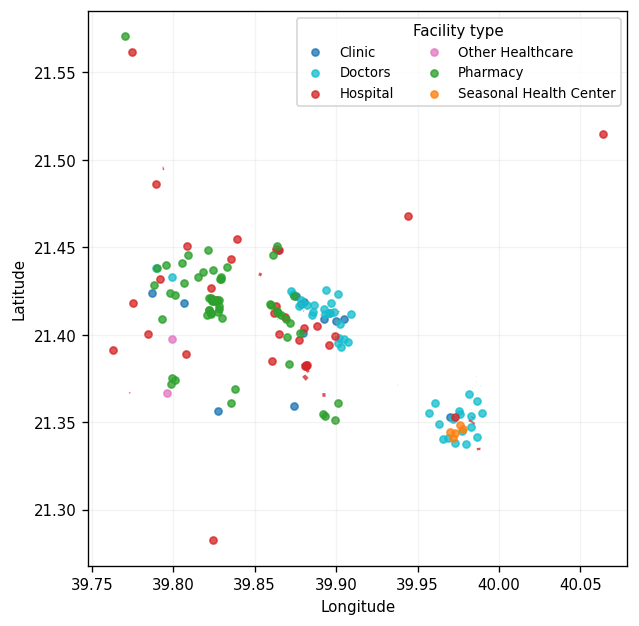

Combined: hajj_drone_project\outputs\figures\paper\combined_v4\figA_medical_infrastructure.png


WindowsPath('hajj_drone_project/outputs/figures/paper/combined_v4/figA_medical_infrastructure.png')

In [25]:
fig,ax=plt.subplots(figsize=(7.2,6))
for cat,g in facilities.groupby("category"):
    g.plot(ax=ax,marker="o",markersize=18,alpha=.78,
           color=FACILITY_COLORS.get(cat,"0.5"),label=cat.replace("_"," ").title())
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(alpha=.15)
ax.legend(title="Facility type",ncol=2,loc="best",frameon=True)
r=save_analytical(fig,"figA_b_medical_infrastructure"); plt.show()
combine("medical_infrastructure_folium.png",r,"figA_medical_infrastructure")

## Figure B. Hajj analytical zones

Saved: hajj_drone_project\outputs\figures\paper\analytical_panels\figB_b_hajj_zones.png


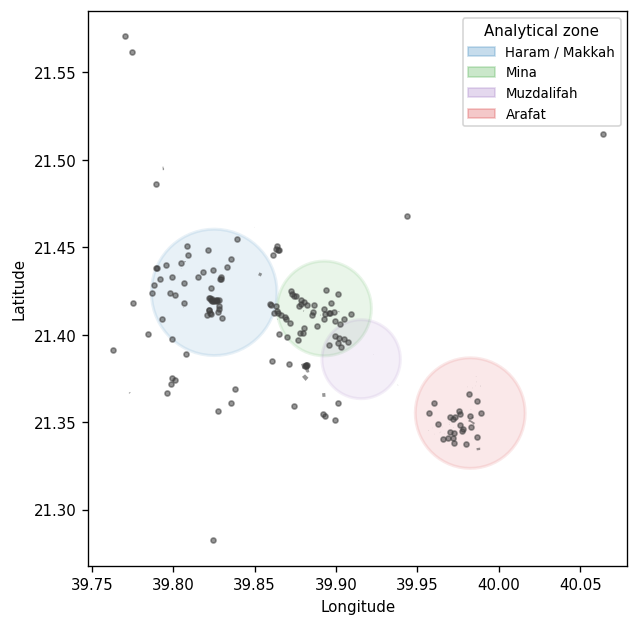

Combined: hajj_drone_project\outputs\figures\paper\combined_v4\figB_hajj_zones.png


WindowsPath('hajj_drone_project/outputs/figures/paper/combined_v4/figB_hajj_zones.png')

In [26]:
fig,ax=plt.subplots(figsize=(7.2,6))
for _,r0 in zones.iterrows():
    c=ZONE_COLORS.get(r0["zone"],"0.5")
    gpd.GeoSeries([r0.geometry],crs=zones.crs).plot(ax=ax,facecolor=c,alpha=.10,edgecolor=c,linewidth=1.8)
facilities.plot(ax=ax,color="0.25",markersize=9,alpha=.55)
handles=[Patch(facecolor=ZONE_COLORS[z],edgecolor=ZONE_COLORS[z],alpha=.25,label=ZONE_LABELS[z]) for z in ZONE_COLORS]
ax.legend(handles=handles,title="Analytical zone",loc="best")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
r=save_analytical(fig,"figB_b_hajj_zones"); plt.show()
combine("hajj_zones_folium.png",r,"figB_hajj_zones")

## Figure C. Grid-resolution comparison

Saved: hajj_drone_project\outputs\figures\paper\figC_grid_resolution_comparison.png


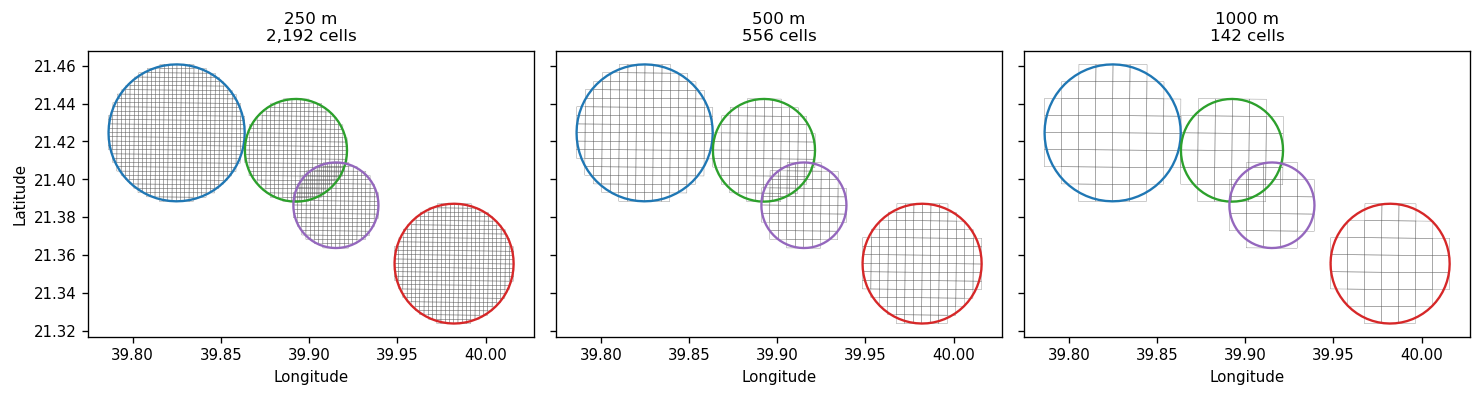

In [27]:
fig,axs=plt.subplots(1,3,figsize=(12.5,4.4),sharex=True,sharey=True)
for ax,g,size in zip(axs,[demand_250,demand_500,demand_1000],[250,500,1000]):
    g.boundary.plot(ax=ax,linewidth=.18,color="0.35")
    plot_zone_boundaries(ax)
    ax.set_title(f"{size} m\n{len(g):,} cells")
    ax.set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")
fig.tight_layout()
save_standalone(fig,"figC_grid_resolution_comparison"); plt.show()

## Figure D. 500 m proxy-demand surface

Saved: hajj_drone_project\outputs\figures\paper\analytical_panels\figD_b_proxy_demand.png


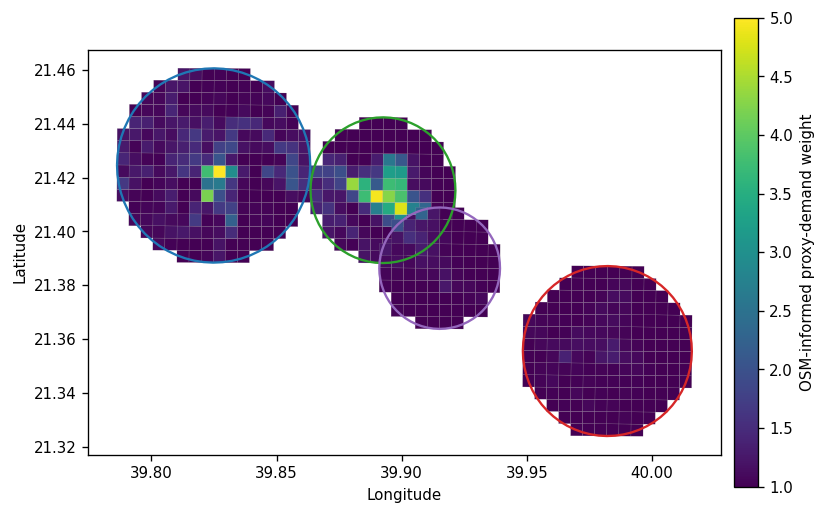

Combined: hajj_drone_project\outputs\figures\paper\combined_v4\figD_proxy_demand.png


WindowsPath('hajj_drone_project/outputs/figures/paper/combined_v4/figD_proxy_demand.png')

In [28]:
fig,ax=plt.subplots(figsize=(7.2,6))
demand_500.plot(ax=ax,column="proxy_demand_weight",cmap="viridis",vmin=1,vmax=5,
                linewidth=.10,edgecolor="0.65")
plot_zone_boundaries(ax)
sm=ScalarMappable(norm=Normalize(1,5),cmap="viridis"); sm.set_array([])
fig.colorbar(sm,ax=ax,fraction=.035,pad=.02,label="OSM-informed proxy-demand weight")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
r=save_analytical(fig,"figD_b_proxy_demand"); plt.show()
combine("proxy_demand_500m_folium.png",r,"figD_proxy_demand")

## Figure E. Candidate hubs over proxy demand

C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_21100\1807344194.py:8: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Candidate hub type",loc="best")


Saved: hajj_drone_project\outputs\figures\paper\analytical_panels\figE_b_candidate_hubs.png


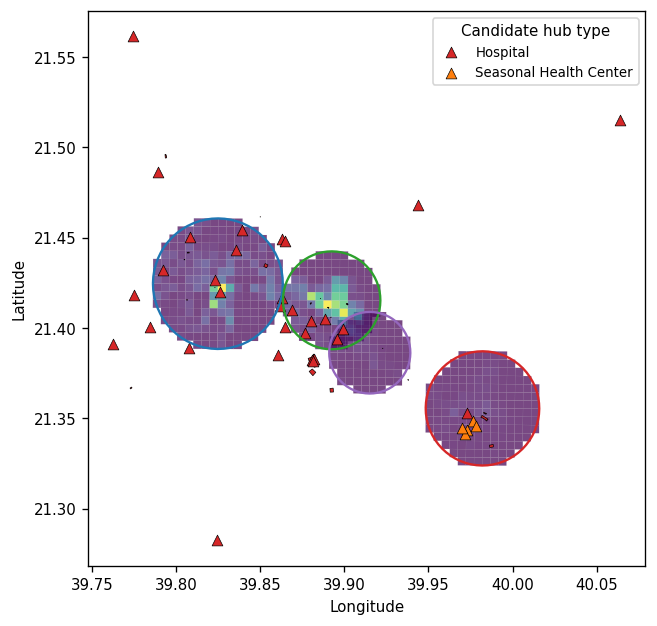

Combined: hajj_drone_project\outputs\figures\paper\combined_v4\figE_candidate_hubs.png


WindowsPath('hajj_drone_project/outputs/figures/paper/combined_v4/figE_candidate_hubs.png')

In [29]:
fig,ax=plt.subplots(figsize=(7.2,6))
demand_500.plot(ax=ax,column="proxy_demand_weight",cmap="viridis",vmin=1,vmax=5,
                linewidth=.06,edgecolor="0.75",alpha=.72)
plot_zone_boundaries(ax)
for cat,g in candidate_hubs.groupby("category"):
    g.plot(ax=ax,marker="^",markersize=42,color=FACILITY_COLORS.get(cat,"black"),
           edgecolor="black",linewidth=.4,label=cat.replace("_"," ").title())
ax.legend(title="Candidate hub type",loc="best")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
r=save_analytical(fig,"figE_b_candidate_hubs"); plt.show()
combine("candidate_hubs_folium.png",r,"figE_candidate_hubs")

## Generate the three missing interactive optimization maps

This section reconstructs the publication solution maps from the saved Notebook 05 checkpoints. It does not rerun optimization.

Outputs:
- `pmedian_proxy_p3_folium.html`
- `pcenter_p3_folium.html`
- `mclp_proxy_p3_5km_folium.html`

They are saved under `outputs/maps/publication_solutions/`.


In [30]:
# ============================================================
# GENERATE INTERACTIVE FOLIUM OPTIMIZATION-SOLUTION MAPS
# ============================================================
import folium
from branca.element import Element
from branca.colormap import linear

SOLUTION_MAP_DIR=PROJECT_ROOT/"outputs"/"maps"/"publication_solutions"
SOLUTION_MAP_DIR.mkdir(parents=True,exist_ok=True)

selected_geo=gpd.GeoDataFrame(
    selected_hubs.copy(),
    geometry=gpd.points_from_xy(selected_hubs["longitude"],selected_hubs["latitude"]),
    crs=4326
)
demand_by_id=demand_500.set_index("demand_point_id")

def map_selected(model,scenario,p,rng=None):
    q=selected_geo[(selected_geo.model==model)&(selected_geo.demand_scenario==scenario)&(selected_geo.p==p)].copy()
    return q[q.range_km.isna()] if rng is None else q[np.isclose(q.range_km.astype(float),rng)]

def map_assignments(model,scenario,p,rng=None):
    q=assignments[(assignments.model==model)&(assignments.demand_scenario==scenario)&(assignments.p==p)].copy()
    return q[q.range_km.isna()] if rng is None else q[np.isclose(q.range_km.astype(float),rng)]

def solution_base():
    return folium.Map(
        location=[float(demand_500.centroid_lat.mean()),float(demand_500.centroid_lon.mean())],
        zoom_start=11,control_scale=True
    )

def add_zones(m):
    fg=folium.FeatureGroup(name="Hajj analytical zones",show=True).add_to(m)
    zcolors={"Haram_Makkah":"#1f77b4","Mina":"#2ca02c","Muzdalifah":"#9467bd","Arafat":"#d62728"}
    for _,r in zones.iterrows():
        c=zcolors.get(r.zone,"#777")
        folium.GeoJson(r.geometry.__geo_interface__,
            style_function=lambda feature,c=c:{"color":c,"weight":2,"fillColor":c,"fillOpacity":.04},
            tooltip=r.zone.replace("_"," ")).add_to(fg)

def legend(m,title,items):
    body="".join(f"<div>{x}</div>" for x in items)
    m.get_root().html.add_child(Element(
        f'<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
        f'border:2px solid #777;border-radius:6px;padding:10px 14px;font-size:12px">'
        f'<b>{title}</b><br>{body}</div>'
    ))

def assignment_map(model,scenario,p,filename,title):
    hs=map_selected(model,scenario,p,None); aa=map_assignments(model,scenario,p,None)
    m=solution_base(); add_zones(m)
    dg=folium.FeatureGroup(name="Demand points",show=True).add_to(m)
    for _,r in demand_500.iterrows():
        folium.CircleMarker([r.centroid_lat,r.centroid_lon],radius=2.2,color="#555",weight=.4,
            fill=True,fill_color="#777",fill_opacity=.35,
            tooltip=f'{r.demand_point_id} | demand {r.proxy_demand_weight:.2f}').add_to(dg)
    ag=folium.FeatureGroup(name="Assignments",show=True).add_to(m)
    lookup=hs.set_index("hub_id")
    for _,r in aa.iterrows():
        if r.assigned_hub_id not in lookup.index: continue
        h=lookup.loc[r.assigned_hub_id]; d=demand_by_id.loc[r.demand_point_id]
        folium.PolyLine([(d.centroid_lat,d.centroid_lon),(h.latitude,h.longitude)],
                        color="#555",weight=.55,opacity=.22).add_to(ag)
    hg=folium.FeatureGroup(name="Selected hubs",show=True).add_to(m)
    for _,h in hs.iterrows():
        folium.Marker([h.latitude,h.longitude],tooltip=f'{h.hub_id}: {h.hub_name}',
            popup=folium.Popup(f'<b>{h.hub_id}</b><br>{h.hub_name}<br>{h.hub_category}<br>{h.hajj_zone}',max_width=350),
            icon=folium.Icon(color="black",icon="plus-sign")).add_to(hg)
    folium.LayerControl(collapsed=False).add_to(m)
    legend(m,title,[f"Selected hubs: p = {p}","Gray lines: demand-to-hub assignments"])
    path=SOLUTION_MAP_DIR/filename; m.save(path); print("Saved:",path)
    return m

pmedian_map=assignment_map("p-median","proxy",3,"pmedian_proxy_p3_folium.html",
                           "Proxy-demand p-median")
pcenter_map=assignment_map("p-center","distance_equity",3,"pcenter_p3_folium.html",
                           "p-center")

# MCLP
hs=map_selected("MCLP","proxy",3,5.0)
cq=mclp_coverage[(mclp_coverage.demand_scenario=="proxy")&(mclp_coverage.p==3)&
                 np.isclose(mclp_coverage.range_km.astype(float),5.0)].copy()
covered_ids=set(cq.loc[cq.covered.astype(bool),"demand_point_id"])
m=solution_base(); add_zones(m)
cm=linear.YlOrRd_09.scale(1,5); cm.caption="OSM-informed proxy-demand weight"; cm.add_to(m)
dg=folium.FeatureGroup(name="Demand cells",show=True).add_to(m)
for _,r in demand_500.iterrows():
    covered=r.demand_point_id in covered_ids
    fill=cm(float(r.proxy_demand_weight)) if covered else "#fff"
    folium.GeoJson(r.geometry.__geo_interface__,
        style_function=lambda feature,fill=fill:{"color":"#666","weight":.35,"fillColor":fill,"fillOpacity":.55},
        tooltip=f'{r.demand_point_id} | demand {r.proxy_demand_weight:.2f} | covered {covered}').add_to(dg)
cg=folium.FeatureGroup(name="5 km service radius",show=True).add_to(m)
hg=folium.FeatureGroup(name="Selected hubs",show=True).add_to(m)
for _,h in hs.iterrows():
    folium.Circle([h.latitude,h.longitude],radius=5000,color="#222",weight=1.5,
                  dash_array="6,5",fill=False).add_to(cg)
    folium.Marker([h.latitude,h.longitude],tooltip=f'{h.hub_id}: {h.hub_name}',
        popup=folium.Popup(f'<b>{h.hub_id}</b><br>{h.hub_name}<br>{h.hub_category}<br>{h.hajj_zone}',max_width=350),
        icon=folium.Icon(color="black",icon="plus-sign")).add_to(hg)
folium.LayerControl(collapsed=False).add_to(m)
legend(m,"Proxy-demand MCLP",["Selected hubs: p = 3","Service radius: R = 5 km",
                             f"Covered cells: {len(covered_ids)} / {len(demand_500)}"])
path=SOLUTION_MAP_DIR/"mclp_proxy_p3_5km_folium.html"; m.save(path); print("Saved:",path)
mclp_map=m

print("\nOpen these files:")
for f in ["pmedian_proxy_p3_folium.html","pcenter_p3_folium.html","mclp_proxy_p3_5km_folium.html"]:
    print(SOLUTION_MAP_DIR/f)

Saved: hajj_drone_project\outputs\maps\publication_solutions\pmedian_proxy_p3_folium.html
Saved: hajj_drone_project\outputs\maps\publication_solutions\pcenter_p3_folium.html
Saved: hajj_drone_project\outputs\maps\publication_solutions\mclp_proxy_p3_5km_folium.html

Open these files:
hajj_drone_project\outputs\maps\publication_solutions\pmedian_proxy_p3_folium.html
hajj_drone_project\outputs\maps\publication_solutions\pcenter_p3_folium.html
hajj_drone_project\outputs\maps\publication_solutions\mclp_proxy_p3_5km_folium.html


## 5. Solution helpers

In [31]:
selected_geo=gpd.GeoDataFrame(
    selected_hubs.copy(),
    geometry=gpd.points_from_xy(selected_hubs["longitude"],selected_hubs["latitude"]),
    crs=4326
)

demand_coords=demand_500[["demand_point_id","centroid_lon","centroid_lat"]].copy()

def get_selected(model,scenario,p,rng=None):
    q=selected_geo[
        (selected_geo["model"]==model)&
        (selected_geo["demand_scenario"]==scenario)&
        (selected_geo["p"]==p)
    ].copy()
    return q[q["range_km"].isna()] if rng is None else q[np.isclose(q["range_km"].astype(float),rng)]

def get_assignments(model,scenario,p,rng=None):
    q=assignments[
        (assignments["model"]==model)&
        (assignments["demand_scenario"]==scenario)&
        (assignments["p"]==p)
    ].copy()
    q=q[q["range_km"].isna()] if rng is None else q[np.isclose(q["range_km"].astype(float),rng)]
    # Coordinates may already exist in saved assignments; add only if absent.
    if "centroid_lon" not in q.columns or "centroid_lat" not in q.columns:
        q=q.merge(demand_coords,on="demand_point_id",how="left")
    return q

## Figure F. Proxy-demand p-median, p=3

Saved: hajj_drone_project\outputs\figures\paper\analytical_panels\figF_b_pmedian_proxy_p3.png


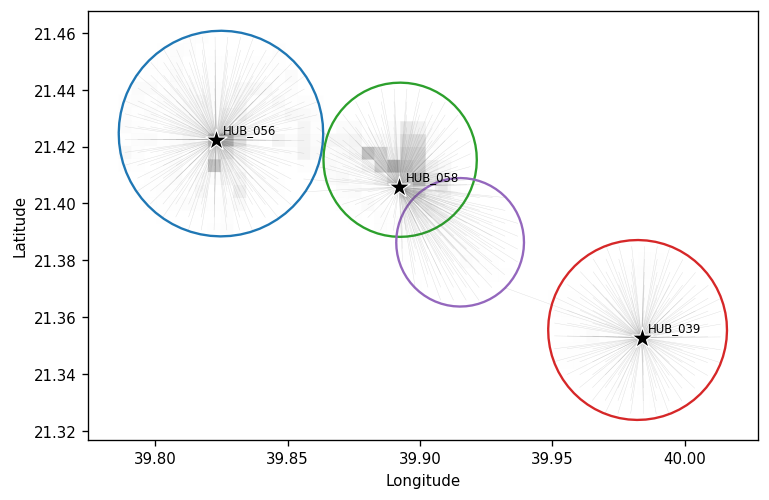

Combined: hajj_drone_project\outputs\figures\paper\combined_v4\figF_pmedian_proxy_p3.png


WindowsPath('hajj_drone_project/outputs/figures/paper/combined_v4/figF_pmedian_proxy_p3.png')

In [32]:
hs=get_selected("p-median","proxy",3,None)
aa=get_assignments("p-median","proxy",3,None)
fig,ax=plt.subplots(figsize=(7.2,6))
demand_500.plot(ax=ax,column="proxy_demand_weight",cmap="Greys",vmin=1,vmax=5,linewidth=0,alpha=.30)
plot_zone_boundaries(ax)
lookup=hs.set_index("hub_id")
for _,x in aa.iterrows():
    if x["assigned_hub_id"] in lookup.index:
        h=lookup.loc[x["assigned_hub_id"]]
        ax.plot([x["centroid_lon"],h["longitude"]],[x["centroid_lat"],h["latitude"]],
                color=".35",linewidth=.25,alpha=.20)
hs.plot(ax=ax,marker="*",markersize=180,color="black",edgecolor="white",linewidth=.7,zorder=5)
for _,h in hs.iterrows():
    ax.annotate(h["hub_id"],(h.longitude,h.latitude),xytext=(4,4),textcoords="offset points",fontsize=7)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
r=save_analytical(fig,"figF_b_pmedian_proxy_p3"); plt.show()
combine("pmedian_p3_folium.png",r,"figF_pmedian_proxy_p3")

## Figure G. p-center, p=3

Saved: hajj_drone_project\outputs\figures\paper\analytical_panels\figG_b_pcenter_p3.png


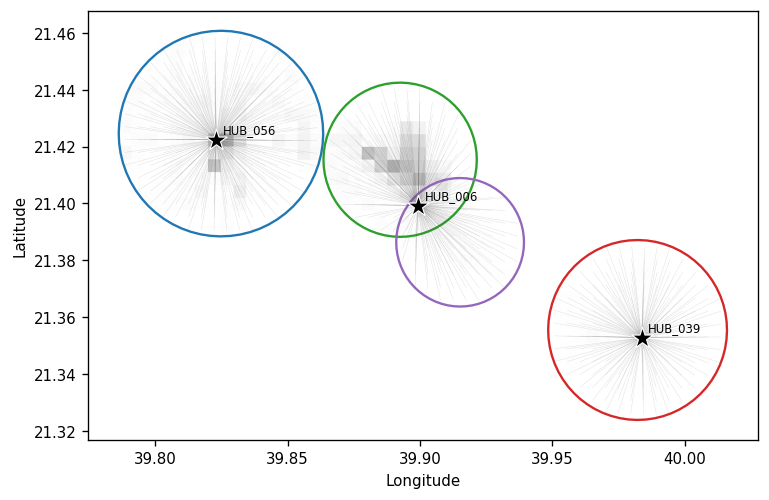

Combined: hajj_drone_project\outputs\figures\paper\combined_v4\figG_pcenter_p3.png


WindowsPath('hajj_drone_project/outputs/figures/paper/combined_v4/figG_pcenter_p3.png')

In [33]:
hs=get_selected("p-center","distance_equity",3,None)
aa=get_assignments("p-center","distance_equity",3,None)
fig,ax=plt.subplots(figsize=(7.2,6))
demand_500.plot(ax=ax,column="proxy_demand_weight",cmap="Greys",vmin=1,vmax=5,linewidth=0,alpha=.30)
plot_zone_boundaries(ax)
lookup=hs.set_index("hub_id")
for _,x in aa.iterrows():
    if x["assigned_hub_id"] in lookup.index:
        h=lookup.loc[x["assigned_hub_id"]]
        ax.plot([x["centroid_lon"],h["longitude"]],[x["centroid_lat"],h["latitude"]],
                color=".35",linewidth=.25,alpha=.20)
hs.plot(ax=ax,marker="*",markersize=180,color="black",edgecolor="white",linewidth=.7,zorder=5)
for _,h in hs.iterrows():
    ax.annotate(h["hub_id"],(h.longitude,h.latitude),xytext=(4,4),textcoords="offset points",fontsize=7)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
r=save_analytical(fig,"figG_b_pcenter_p3"); plt.show()
combine("pcenter_p3_folium.png",r,"figG_pcenter_p3")

## Figure H. Proxy-demand MCLP, p=3, R=5 km

Selected hubs: ['HUB_006', 'HUB_015', 'HUB_039']
Covered demand cells: 556
Uncovered demand cells: 0
Geographic coverage: 100.00%
Saved: hajj_drone_project\outputs\figures\paper\analytical_panels\figH_b_mclp_proxy_p3_5km.png


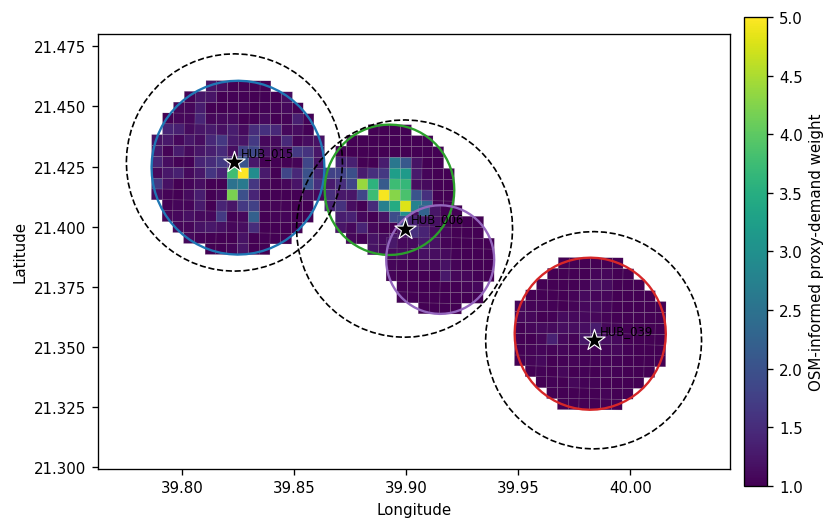

Combined: hajj_drone_project\outputs\figures\paper\combined_v4\figH_mclp_proxy_p3_5km.png


WindowsPath('hajj_drone_project/outputs/figures/paper/combined_v4/figH_mclp_proxy_p3_5km.png')

In [34]:
# ============================================================
# FIGURE H
# Proxy-demand MCLP, p = 3, R = 5 km
# ============================================================

hs = get_selected(
    "MCLP",
    "proxy",
    3,
    5.0
)

cq = mclp_coverage[
    (mclp_coverage["demand_scenario"] == "proxy") &
    (mclp_coverage["p"] == 3) &
    np.isclose(
        mclp_coverage["range_km"].astype(float),
        5.0
    )
].copy()


# ------------------------------------------------------------
# Coverage status
# ------------------------------------------------------------

covered_ids = set(
    cq.loc[
        cq["covered"].astype(bool),
        "demand_point_id"
    ]
)

pg = demand_500.copy()

pg["covered"] = (
    pg["demand_point_id"]
    .isin(covered_ids)
)

covered = pg[
    pg["covered"]
].copy()

uncovered = pg[
    ~pg["covered"]
].copy()


print("Selected hubs:", hs["hub_id"].tolist())

print(
    "Covered demand cells:",
    len(covered)
)

print(
    "Uncovered demand cells:",
    len(uncovered)
)

print(
    "Geographic coverage:",
    f"{100 * len(covered) / len(pg):.2f}%"
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 6)
)


# IMPORTANT:
# GeoPandas cannot reliably plot an empty GeoDataFrame.
if not uncovered.empty:

    uncovered.plot(
        ax=ax,
        facecolor="white",
        edgecolor="0.75",
        linewidth=0.10
    )


if not covered.empty:

    covered.plot(
        ax=ax,
        column="proxy_demand_weight",
        cmap="viridis",
        vmin=1,
        vmax=5,
        edgecolor="0.65",
        linewidth=0.10
    )


# ------------------------------------------------------------
# Analytical Hajj zones
# ------------------------------------------------------------

plot_zone_boundaries(ax)


# ------------------------------------------------------------
# 5 km service areas
# ------------------------------------------------------------

metric_crs = (
    candidate_hubs
    .estimate_utm_crs()
)

metric_hubs = (
    hs
    .to_crs(metric_crs)
    .copy()
)

buffers = metric_hubs.copy()

buffers["geometry"] = (
    metric_hubs.geometry
    .buffer(5000)
)

buffers = buffers.to_crs(4326)

buffers.boundary.plot(
    ax=ax,
    color="black",
    linestyle="--",
    linewidth=1.0,
    zorder=4
)


# ------------------------------------------------------------
# Selected hubs
# ------------------------------------------------------------

hs.plot(
    ax=ax,
    marker="*",
    markersize=180,
    color="black",
    edgecolor="white",
    linewidth=0.7,
    zorder=5
)


for _, h in hs.iterrows():

    ax.annotate(
        h["hub_id"],
        (
            h["longitude"],
            h["latitude"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        zorder=6
    )


# ------------------------------------------------------------
# Demand colorbar
# ------------------------------------------------------------

sm = ScalarMappable(
    norm=Normalize(
        vmin=1,
        vmax=5
    ),
    cmap="viridis"
)

sm.set_array([])

fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02,
    label="OSM-informed proxy-demand weight"
)


ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")


# ------------------------------------------------------------
# Save analytical panel
# ------------------------------------------------------------

r = save_analytical(
    fig,
    "figH_b_mclp_proxy_p3_5km"
)

plt.show()


# ------------------------------------------------------------
# Create side-by-side figure if Folium PNG exists
# ------------------------------------------------------------

combine(
    "mclp_p3_5km_folium.png",
    r,
    "figH_mclp_proxy_p3_5km"
)

## Figure I. p-median diminishing returns

Saved: hajj_drone_project\outputs\figures\paper\figI_pmedian_diminishing_returns.png


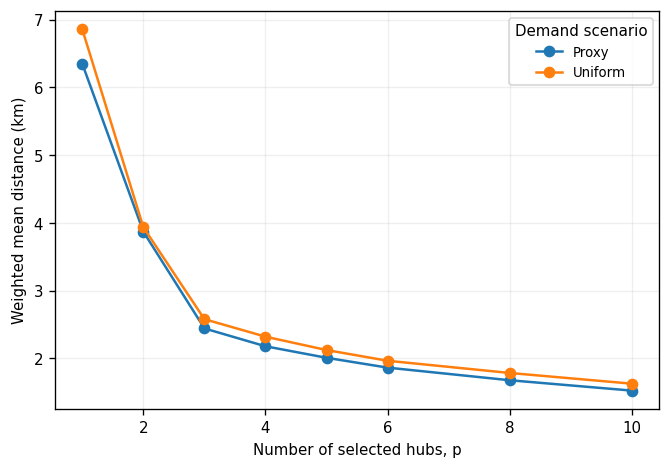

In [35]:
pm=run_summary[(run_summary["model"]=="p-median")&run_summary["range_km"].isna()].copy()
fig,ax=plt.subplots(figsize=(6.5,4.3))
for sc,g in pm.groupby("demand_scenario"):
    g=g.sort_values("p")
    ax.plot(g["p"],g["weighted_mean_distance_km"],marker="o",label=sc.title())
ax.set_xlabel("Number of selected hubs, p"); ax.set_ylabel("Weighted mean distance (km)")
ax.grid(alpha=.2); ax.legend(title="Demand scenario")
save_standalone(fig,"figI_pmedian_diminishing_returns"); plt.show()

## Figure J. MCLP proxy-demand coverage curves

Saved: hajj_drone_project\outputs\figures\paper\figJ_mclp_coverage_curves.png


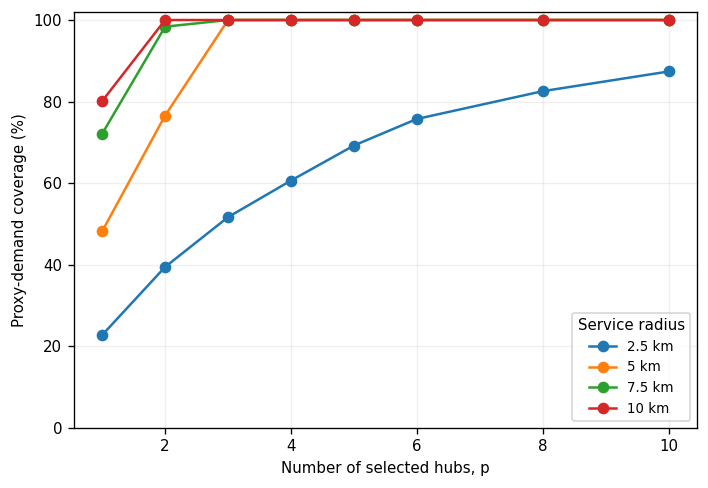

In [36]:
mc=run_summary[(run_summary["model"]=="MCLP")&(run_summary["demand_scenario"]=="proxy")].copy()
fig,ax=plt.subplots(figsize=(6.7,4.5))
for rng,g in mc.groupby("range_km"):
    g=g.sort_values("p")
    ax.plot(g["p"],g["weighted_coverage_pct"],marker="o",label=f"{rng:g} km")
ax.set_xlabel("Number of selected hubs, p"); ax.set_ylabel("Proxy-demand coverage (%)")
ax.set_ylim(0,102); ax.grid(alpha=.2); ax.legend(title="Service radius")
save_standalone(fig,"figJ_mclp_coverage_curves"); plt.show()

## Figure K. Candidate-hub selection frequency

Saved: hajj_drone_project\outputs\figures\paper\figK_hub_selection_frequency.png


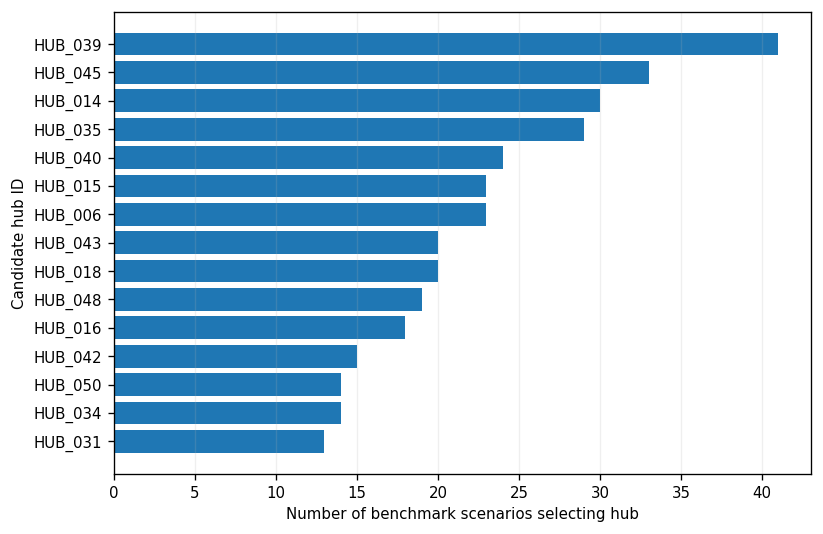

,hub_id,hub_name,hub_category,hajj_zone,selection_count
27,HUB_039,Jabal Al-Rahmah Hospital,hospital,Arafat,41
33,HUB_045,Hilal Ahmar,hospital,Muzdalifah,33
6,HUB_014,مستوصف العبير,hospital,Greater_Makkah,30
24,HUB_035,MarkazSihhiMawsimiRaqmSittat'Ashar,seasonal_health_center,Arafat,29
28,HUB_040,Mina Al-Share’a Al-Jadeed Hospital,hospital,Mina,24
2,HUB_006,Armed Forces Hospital,hospital,Mina,23
7,HUB_015,Al Haram Emergency Hospital,hospital,Haram_Makkah,23
10,HUB_018,Al Fahd Medical Complex,hospital,Haram_Makkah,20
31,HUB_043,Hospital Shifa,hospital,Haram_Makkah,20
36,HUB_048,King Faisal Hospital,hospital,Haram_Makkah,19


In [37]:
freq=(selected_hubs.groupby(["hub_id","hub_name","hub_category","hajj_zone"])
      .size().rename("selection_count").reset_index()
      .sort_values("selection_count",ascending=False).head(15))
fig,ax=plt.subplots(figsize=(7.5,5))
q=freq.sort_values("selection_count")
ax.barh(q["hub_id"],q["selection_count"])
ax.set_xlabel("Number of benchmark scenarios selecting hub"); ax.set_ylabel("Candidate hub ID")
ax.grid(axis="x",alpha=.2)
save_standalone(fig,"figK_hub_selection_frequency"); plt.show()
display(freq)

## 6. Publication-ready tables

In [39]:
table_pmedian=run_summary[
    (run_summary["model"]=="p-median")&
    (run_summary["demand_scenario"]=="proxy")&
    run_summary["range_km"].isna()
][["p","weighted_mean_distance_km","max_distance_km","selected_hubs"]].sort_values("p")

table_lscp=run_summary[run_summary["model"]=="LSCP"][
    ["range_km","p","termination","uncoverable_points","selected_hubs"]
].sort_values("range_km")

table_mclp25=run_summary[
    (run_summary["model"]=="MCLP")&
    (run_summary["demand_scenario"]=="proxy")&
    np.isclose(run_summary["range_km"].astype(float),2.5)
][["p","geographic_coverage_pct","weighted_coverage_pct","selected_hubs"]].sort_values("p")

display(table_pmedian); display(table_lscp); display(table_mclp25)
table_pmedian.to_csv(REPORT_DIR/"paper_table_pmedian_proxy.csv",index=False)
table_lscp.to_csv(REPORT_DIR/"paper_table_lscp.csv",index=False)
table_mclp25.to_csv(REPORT_DIR/"paper_table_mclp_2p5km_proxy.csv",index=False)

,p,weighted_mean_distance_km,max_distance_km,selected_hubs
16,1.0,6.348224,14.614218,HUB_012
18,2.0,3.869103,7.977337,HUB_007;HUB_014
20,3.0,2.440699,5.703506,HUB_039;HUB_056;HUB_058
22,4.0,2.177170,4.262816,HUB_039;HUB_040;HUB_045;HUB_056
24,5.0,2.007293,4.300618,HUB_016;HUB_039;HUB_040;HUB_045;HUB_050
26,6.0,1.861917,3.833639,HUB_016;HUB_039;HUB_040;HUB_045;HUB_048;HUB_049
28,8.0,1.675662,3.833639,HUB_006;HUB_016;HUB_039;HUB_041;HUB_043;HUB_04...
30,10.0,1.522619,3.833639,HUB_014;HUB_016;HUB_017;HUB_018;HUB_036;HUB_03...


,range_km,p,termination,uncoverable_points,selected_hubs
104,2.5,NaN,infeasible_precheck,47.0,NaN
105,5.0,3.0,optimal,0.0,HUB_006;HUB_007;HUB_016
106,7.5,3.0,optimal,0.0,HUB_007;HUB_047;HUB_048
107,10.0,2.0,optimal,0.0,HUB_047;HUB_054


,p,geographic_coverage_pct,weighted_coverage_pct,selected_hubs
72,1.0,16.187050,22.720246,HUB_040
73,2.0,30.395683,39.418265,HUB_016;HUB_040
74,3.0,44.784173,51.645905,HUB_016;HUB_035;HUB_040
75,4.0,54.496403,60.618865,HUB_035;HUB_043;HUB_048;HUB_058
76,5.0,65.287770,69.210492,HUB_018;HUB_035;HUB_040;HUB_043;HUB_045
77,6.0,71.582734,75.728661,HUB_035;HUB_040;HUB_043;HUB_045;HUB_048;HUB_050
78,8.0,79.496403,82.545284,HUB_007;HUB_018;HUB_020;HUB_042;HUB_043;HUB_04...
79,10.0,84.712230,87.375778,HUB_007;HUB_014;HUB_016;HUB_018;HUB_021;HUB_02...


# Repository and manuscript use

For the manuscript, use the combined figures under `outputs/figures/paper/combined_v4/` and the standalone quantitative PDFs.

For GitHub, retain the original interactive Folium HTML maps in addition to the static figures. Describe the released artifact as a **reproducible Hajj medical-logistics geospatial dataset and open-source construction pipeline**. Include provenance, OSM attribution/licensing, retrieval dates, a data dictionary, environment specification, and the notebooks/scripts needed to regenerate derived data.

Do not claim that the dataset is the first of its kind until a literature and repository search verifies that statement.